# 08 LPIPS Perceptual Metrics — OpenCV Telea Baseline

This notebook computes LPIPS perceptual distances for the OpenCV Telea baseline on the 50-painting controlled subset.

The notebook compares:

1. clean image vs damaged image,
2. clean image vs OpenCV-restored image.

LPIPS is computed for image-like spatial regions only:

- full image,
- painting content region,
- mask bounding-box crop.

Sparse masked pixels are not used directly for LPIPS because LPIPS expects spatial image inputs, not unordered pixel sets.

Lower LPIPS means higher perceptual similarity. Therefore:

`lpips_improvement = damaged_lpips - restored_lpips`

Positive LPIPS improvement means the restored image is perceptually closer to the clean reference than the damaged input.

In [1]:
from pathlib import Path
import sys
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

CONFIG_PATH = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Source directory exists:", SRC_DIR.exists())
print("Config path:", CONFIG_PATH)
print("Config exists:", CONFIG_PATH.exists())

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Source directory not found: {SRC_DIR}")

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Experiment config not found: {CONFIG_PATH}")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Source directory exists: True
Config path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml
Config exists: True


In [2]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from restoration_eval.metrics_lpips import (
    DEFAULT_LPIPS_NET,
    DEFAULT_CROP_RESIZE,
    DEFAULT_MASK_BBOX_MARGIN,
    get_device,
    load_lpips_model,
    compute_lpips_metrics_for_restorations,
    validate_lpips_metrics,
    summarize_lpips_metrics,
    rank_lpips_cases,
)

with CONFIG_PATH.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths_cfg = config.get("paths", {})
preprocessing_cfg = config.get("preprocessing", {})

processed_metadata_path = PROJECT_ROOT / paths_cfg["processed_metadata_dir"] / "metadata_processed_clean.csv"
restored_metadata_path = PROJECT_ROOT / paths_cfg["processed_metadata_dir"] / "metadata_restored_opencv_telea.csv"

metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
metrics_dir.mkdir(parents=True, exist_ok=True)

lpips_metrics_path = metrics_dir / "lpips_metrics_opencv_telea_50.csv"
summary_by_region_path = metrics_dir / "lpips_summary_by_region_opencv_telea_50.csv"
summary_by_mask_type_path = metrics_dir / "lpips_summary_by_mask_type_opencv_telea_50.csv"
summary_by_category_path = metrics_dir / "lpips_summary_by_category_opencv_telea_50.csv"
summary_by_region_mask_type_path = metrics_dir / "lpips_summary_by_region_mask_type_opencv_telea_50.csv"
summary_by_region_category_path = metrics_dir / "lpips_summary_by_region_category_opencv_telea_50.csv"

lpips_strongest_cases_path = metrics_dir / "lpips_strongest_mask_bbox_cases_opencv_telea_50.csv"
lpips_weakest_cases_path = metrics_dir / "lpips_weakest_mask_bbox_cases_opencv_telea_50.csv"

target_size = (
    preprocessing_cfg.get("output_size")
    or preprocessing_cfg.get("target_size")
    or config.get("experiment", {}).get("image_size")
    or 768
)

lpips_net = DEFAULT_LPIPS_NET
crop_resize = DEFAULT_CROP_RESIZE
mask_bbox_margin = DEFAULT_MASK_BBOX_MARGIN

print("Processed metadata path:", processed_metadata_path)
print("Processed metadata exists:", processed_metadata_path.exists())
print("Restored metadata path:", restored_metadata_path)
print("Restored metadata exists:", restored_metadata_path.exists())
print("LPIPS metrics output:", lpips_metrics_path)
print("Target size:", target_size)
print("LPIPS net:", lpips_net)
print("Crop resize:", crop_resize)
print("Mask bbox margin:", mask_bbox_margin)

if not processed_metadata_path.exists():
    raise FileNotFoundError(
        f"Processed metadata not found: {processed_metadata_path}. "
        "Run Notebook 02 first."
    )

if not restored_metadata_path.exists():
    raise FileNotFoundError(
        f"OpenCV restoration metadata not found: {restored_metadata_path}. "
        "Run Notebook 05 first."
    )

processed_metadata_df = pd.read_csv(processed_metadata_path)
restored_metadata_df = pd.read_csv(restored_metadata_path)

print("\nProcessed metadata shape:", processed_metadata_df.shape)
print("Restored metadata shape:", restored_metadata_df.shape)

display(processed_metadata_df.head())
display(restored_metadata_df.head())

Processed metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Processed metadata exists: True
Restored metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_telea.csv
Restored metadata exists: True
LPIPS metrics output: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_opencv_telea_50.csv
Target size: 768
LPIPS net: alex
Crop resize: 256
Mask bbox margin: 32

Processed metadata shape: (50, 43)
Restored metadata shape: (250, 20)


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,padding_color_b,content_x_min,content_y_min,content_x_max,content_y_max,content_width,content_height,preprocessing_method,content_area_pixels,content_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,20,52,0,715,768,663,768,aspect_ratio_resize_median_rgb_pad,509184,86.33
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,35,159,0,608,768,449,768,aspect_ratio_resize_median_rgb_pad,344832,58.46
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,39,77,0,691,768,614,768,aspect_ratio_resize_median_rgb_pad,471552,79.95
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,62,0,71,768,696,768,625,aspect_ratio_resize_median_rgb_pad,480000,81.38
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,34,99,0,668,768,569,768,aspect_ratio_resize_median_rgb_pad,436992,74.09


,case_id,painting_id,mask_id,mask_type,model_name,algorithm,inpaint_radius,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,restored_filename,restored_path,damaged_area_pixels,damaged_area_percentage_content,damaged_area_percentage_full,status,issue
0,p001_loss_large,p001,p001_loss_large,loss_large,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,67242,13.2058,11.4003,ok,NaN
1,p001_loss_small,p001,p001_loss_small,loss_small,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,24198,4.7523,4.1026,ok,NaN
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,44392,8.7183,7.5263,ok,NaN
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,8012,1.5735,1.3584,ok,NaN
4,p001_zero_control,p001,p001_zero_control,zero_control,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,0,0.0000,0.0000,ok,NaN


In [3]:
# Merge OpenCV restoration metadata with processed painting metadata

metadata_columns_to_add = [
    "painting_id",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "content_width",
    "content_height",
]

missing_processed_columns = [
    col for col in metadata_columns_to_add
    if col not in processed_metadata_df.columns
]

if missing_processed_columns:
    raise ValueError(
        f"Processed metadata is missing required columns for LPIPS evaluation: "
        f"{missing_processed_columns}"
    )

processed_subset_df = processed_metadata_df[metadata_columns_to_add].copy()

lpips_input_df = restored_metadata_df.merge(
    processed_subset_df,
    on="painting_id",
    how="left",
    validate="many_to_one",
)

print("LPIPS input shape:", lpips_input_df.shape)

required_lpips_input_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_id",
    "mask_type",
    "model_name",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_lpips_input_columns = [
    col for col in required_lpips_input_columns
    if col not in lpips_input_df.columns
]

print("\nRequired-column check:")
if missing_lpips_input_columns:
    print("Missing columns:", missing_lpips_input_columns)
else:
    print("All required LPIPS input columns are present.")

print("\nRow counts:")
print("Restored metadata rows:", len(restored_metadata_df))
print("LPIPS input rows:", len(lpips_input_df))

print("\nMask type counts:")
display(lpips_input_df["mask_type"].value_counts().sort_index())

print("\nCategory counts:")
display(lpips_input_df["category"].value_counts().sort_index())

print("\nRestoration status counts:")
display(lpips_input_df["status"].value_counts(dropna=False))

print("\nIssue counts:")
display(lpips_input_df["issue"].fillna("").replace("", "ok").value_counts())

if missing_lpips_input_columns:
    raise ValueError("LPIPS input metadata is missing required columns.")

if len(lpips_input_df) != 250:
    raise ValueError(f"Expected 250 OpenCV restoration rows, found {len(lpips_input_df)}.")

if lpips_input_df["case_id"].duplicated().any():
    duplicate_cases = lpips_input_df.loc[
        lpips_input_df["case_id"].duplicated(),
        "case_id",
    ].tolist()
    raise ValueError(f"Duplicate case IDs found: {duplicate_cases[:10]}")

if lpips_input_df["category"].isna().any():
    missing_category_rows = lpips_input_df[lpips_input_df["category"].isna()]
    display(missing_category_rows[["case_id", "painting_id", "mask_type"]])
    raise ValueError("Some LPIPS rows are missing category values.")

if (lpips_input_df["status"] != "ok").any():
    failed_rows = lpips_input_df[lpips_input_df["status"] != "ok"]
    display(failed_rows)
    raise ValueError("Some OpenCV restoration rows have non-ok status.")

print("\nLPIPS input metadata gate passed.")
display(lpips_input_df.head())

LPIPS input shape: (250, 28)

Required-column check:
All required LPIPS input columns are present.

Row counts:
Restored metadata rows: 250
LPIPS input rows: 250

Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64


Category counts:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64


Restoration status counts:


status
ok    250
Name: count, dtype: int64


Issue counts:


issue
ok    250
Name: count, dtype: int64


LPIPS input metadata gate passed.


,case_id,painting_id,mask_id,mask_type,model_name,algorithm,inpaint_radius,clean_filename,clean_path,mask_filename,...,status,issue,category,title,content_x_min,content_y_min,content_x_max,content_y_max,content_width,content_height
0,p001_loss_large,p001,p001_loss_large,loss_large,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
1,p001_loss_small,p001,p001_loss_small,loss_small,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
4,p001_zero_control,p001,p001_zero_control,zero_control,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768


In [4]:
# Load LPIPS model

device = get_device(prefer_cuda=True)

print("Selected device:", device)

lpips_model = load_lpips_model(
    net=lpips_net,
    device=device,
)

print("LPIPS model loaded.")
print("LPIPS net:", lpips_net)
print("Device:", device)

Selected device: cuda
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(mode

LPIPS model loaded.
LPIPS net: alex
Device: cuda


In [5]:
# One-painting LPIPS test

test_painting_id = (
    lpips_input_df
    .sort_values("painting_id")
    .iloc[0]["painting_id"]
)

test_lpips_input_df = (
    lpips_input_df[lpips_input_df["painting_id"] == test_painting_id]
    .copy()
)

print("Test painting ID:", test_painting_id)
print("Input rows:", len(test_lpips_input_df))

display(
    test_lpips_input_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "model_name",
            "damaged_area_percentage_content",
        ]
    ].sort_values("mask_type")
)

test_lpips_metrics_df = compute_lpips_metrics_for_restorations(
    restoration_metadata=test_lpips_input_df,
    lpips_model=lpips_model,
    device=device,
    lpips_net=lpips_net,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    crop_resize=crop_resize,
    progress_every=1,
)

print("Generated test LPIPS rows:", len(test_lpips_metrics_df))
print("Expected test LPIPS rows: 14")

print("\nRows by evaluation region:")
display(test_lpips_metrics_df["evaluation_region"].value_counts().sort_index())

print("\nRows by mask type:")
display(test_lpips_metrics_df["mask_type"].value_counts().sort_index())

print("\nStatus counts:")
display(test_lpips_metrics_df["status"].value_counts(dropna=False))

print("\nIssue counts:")
display(test_lpips_metrics_df["issue"].fillna("").replace("", "ok").value_counts())

display(test_lpips_metrics_df)

Test painting ID: p001
Input rows: 5


,case_id,painting_id,category,mask_type,model_name,damaged_area_percentage_content
0,p001_loss_large,p001,portrait_figure,loss_large,opencv_telea,13.2058
1,p001_loss_small,p001,portrait_figure,loss_small,opencv_telea,4.7523
2,p001_mixed_damage,p001,portrait_figure,mixed_damage,opencv_telea,8.7183
3,p001_scratch_thin,p001,portrait_figure,scratch_thin,opencv_telea,1.5735
4,p001_zero_control,p001,portrait_figure,zero_control,opencv_telea,0.0000


Starting LPIPS computation for 5 restoration cases...
Expected LPIPS metric rows: 14
Device: cuda
LPIPS net: alex
Processed 1/5 restoration cases...
Processed 2/5 restoration cases...
Processed 3/5 restoration cases...
Processed 4/5 restoration cases...
Processed 5/5 restoration cases...
LPIPS computation finished.
Generated test LPIPS rows: 14
Expected test LPIPS rows: 14

Rows by evaluation region:


evaluation_region
content_region    5
full_image        5
mask_bbox_crop    4
Name: count, dtype: int64


Rows by mask type:


...


Status counts:


status
ok    14
Name: count, dtype: int64


Issue counts:


issue
ok    14
Name: count, dtype: int64

,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,damaged_area_percentage_content,damaged_area_percentage_full,damaged_lpips,restored_lpips,lpips_improvement,lpips_net,crop_resize,device,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,full_image,589824,0,...,13.2058,11.4003,0.264050,0.088961,0.175089,alex,256,cuda,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,content_region,509184,52,...,13.2058,11.4003,0.288218,0.101456,0.186762,alex,256,cuda,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,mask_bbox_crop,178929,197,...,13.2058,11.4003,0.592107,0.273881,0.318226,alex,256,cuda,ok,
3,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,full_image,589824,0,...,4.7523,4.1026,0.335288,0.005583,0.329705,alex,256,cuda,ok,
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,content_region,509184,52,...,4.7523,4.1026,0.318926,0.006440,0.312486,alex,256,cuda,ok,
5,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,mask_bbox_crop,471969,48,...,4.7523,4.1026,0.341009,0.007826,0.333183,alex,256,cuda,ok,
6,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,p001_mixed_damage,mixed_damage,opencv_telea,full_image,589824,0,...,8.7183,7.5263,0.416328,0.030484,0.385844,alex,256,cuda,ok,
7,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,p001_mixed_damage,mixed_damage,opencv_telea,content_region,509184,52,...,8.7183,7.5263,0.436847,0.030697,0.406150,alex,256,cuda,ok,
8,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,p001_mixed_damage,mixed_damage,opencv_telea,mask_bbox_crop,589824,0,...,8.7183,7.5263,0.416328,0.030484,0.385844,alex,256,cuda,ok,
9,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,p001_scratch_thin,scratch_thin,opencv_telea,full_image,589824,0,...,1.5735,1.3584,0.425347,0.005461,0.419886,alex,256,cuda,ok,


In [6]:
# Inspect one-painting LPIPS sanity

print("Zero-control LPIPS rows:")
zero_lpips_test_df = test_lpips_metrics_df[
    test_lpips_metrics_df["mask_type"] == "zero_control"
].copy()

display(
    zero_lpips_test_df[
        [
            "case_id",
            "evaluation_region",
            "damaged_lpips",
            "restored_lpips",
            "lpips_improvement",
        ]
    ]
)

print("\nNon-zero LPIPS example:")
nonzero_lpips_test_df = test_lpips_metrics_df[
    test_lpips_metrics_df["mask_type"] != "zero_control"
].copy()

example_case_id = (
    nonzero_lpips_test_df
    .sort_values(["mask_type", "evaluation_region"])
    .iloc[0]["case_id"]
)

example_lpips_df = nonzero_lpips_test_df[
    nonzero_lpips_test_df["case_id"] == example_case_id
].copy()

print("Example case:", example_case_id)

display(
    example_lpips_df[
        [
            "case_id",
            "mask_type",
            "evaluation_region",
            "region_pixel_count",
            "damaged_lpips",
            "restored_lpips",
            "lpips_improvement",
            "lpips_net",
            "crop_resize",
            "device",
        ]
    ]
)

print("\nLPIPS value ranges in test:")
display(
    test_lpips_metrics_df[
        ["damaged_lpips", "restored_lpips", "lpips_improvement"]
    ].describe().round(5)
)

Zero-control LPIPS rows:


,case_id,evaluation_region,damaged_lpips,restored_lpips,lpips_improvement
12,p001_zero_control,full_image,0.0,0.0,0.0
13,p001_zero_control,content_region,0.0,0.0,0.0



Non-zero LPIPS example:
Example case: p001_loss_large


,case_id,mask_type,evaluation_region,region_pixel_count,damaged_lpips,restored_lpips,lpips_improvement,lpips_net,crop_resize,device
0,p001_loss_large,loss_large,full_image,589824,0.264050,0.088961,0.175089,alex,256,cuda
1,p001_loss_large,loss_large,content_region,509184,0.288218,0.101456,0.186762,alex,256,cuda
2,p001_loss_large,loss_large,mask_bbox_crop,178929,0.592107,0.273881,0.318226,alex,256,cuda



LPIPS value ranges in test:


,damaged_lpips,restored_lpips,lpips_improvement
count,14.00000,14.00000,14.00000
mean,0.33581,0.04214,0.29367
std,0.16393,0.07409,0.14786
min,0.00000,0.00000,0.00000
25%,0.29590,0.00546,0.21819
50%,0.37867,0.00713,0.33144
75%,0.42535,0.03064,0.40107
max,0.59211,0.27388,0.43833


In [7]:
# Compute LPIPS metrics for all OpenCV restoration cases

lpips_metrics_df = compute_lpips_metrics_for_restorations(
    restoration_metadata=lpips_input_df,
    lpips_model=lpips_model,
    device=device,
    lpips_net=lpips_net,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    crop_resize=crop_resize,
    progress_every=50,
)

print("LPIPS metric computation complete.")
print("Rows:", len(lpips_metrics_df))
print("Expected rows: 700")

print("\nRows by evaluation region:")
display(lpips_metrics_df["evaluation_region"].value_counts().sort_index())

print("\nRows by mask type:")
display(lpips_metrics_df["mask_type"].value_counts().sort_index())

print("\nStatus counts:")
display(lpips_metrics_df["status"].value_counts(dropna=False))

print("\nIssue counts:")
display(lpips_metrics_df["issue"].fillna("").replace("", "ok").value_counts())

display(lpips_metrics_df.head())

Starting LPIPS computation for 250 restoration cases...
Expected LPIPS metric rows: 700
Device: cuda
LPIPS net: alex
Processed 1/250 restoration cases...
Processed 50/250 restoration cases...
Processed 100/250 restoration cases...
Processed 150/250 restoration cases...
Processed 200/250 restoration cases...
Processed 250/250 restoration cases...
LPIPS computation finished.
LPIPS metric computation complete.
Rows: 700
Expected rows: 700

Rows by evaluation region:


evaluation_region
content_region    250
full_image        250
mask_bbox_crop    200
Name: count, dtype: int64


Rows by mask type:


mask_type
loss_large      150
loss_small      150
mixed_damage    150
scratch_thin    150
zero_control    100
Name: count, dtype: int64


Status counts:


status
ok    700
Name: count, dtype: int64


Issue counts:


issue
ok    700
Name: count, dtype: int64

,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,damaged_area_percentage_content,damaged_area_percentage_full,damaged_lpips,restored_lpips,lpips_improvement,lpips_net,crop_resize,device,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,full_image,589824,0,...,13.2058,11.4003,0.264050,0.088961,0.175089,alex,256,cuda,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,content_region,509184,52,...,13.2058,11.4003,0.288218,0.101456,0.186762,alex,256,cuda,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,mask_bbox_crop,178929,197,...,13.2058,11.4003,0.592107,0.273881,0.318226,alex,256,cuda,ok,
3,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,full_image,589824,0,...,4.7523,4.1026,0.335288,0.005583,0.329705,alex,256,cuda,ok,
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,content_region,509184,52,...,4.7523,4.1026,0.318926,0.006440,0.312486,alex,256,cuda,ok,


In [8]:
# Save full LPIPS metrics

lpips_metrics_df.to_csv(lpips_metrics_path, index=False)

print("LPIPS metrics saved:")
print(lpips_metrics_path)
print("Saved file exists:", lpips_metrics_path.exists())
print("Rows saved:", len(lpips_metrics_df))
print("Columns:", len(lpips_metrics_df.columns))

reloaded_lpips_metrics_df = pd.read_csv(lpips_metrics_path)

print("\nReloaded shape:", reloaded_lpips_metrics_df.shape)
display(reloaded_lpips_metrics_df.head())

LPIPS metrics saved:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_opencv_telea_50.csv
Saved file exists: True
Rows saved: 700
Columns: 24

Reloaded shape: (700, 24)


,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,damaged_area_percentage_content,damaged_area_percentage_full,damaged_lpips,restored_lpips,lpips_improvement,lpips_net,crop_resize,device,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,full_image,589824,0,...,13.2058,11.4003,0.264050,0.088961,0.175089,alex,256,cuda,ok,NaN
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,content_region,509184,52,...,13.2058,11.4003,0.288218,0.101456,0.186762,alex,256,cuda,ok,NaN
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,mask_bbox_crop,178929,197,...,13.2058,11.4003,0.592107,0.273881,0.318226,alex,256,cuda,ok,NaN
3,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,full_image,589824,0,...,4.7523,4.1026,0.335288,0.005583,0.329705,alex,256,cuda,ok,NaN
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,content_region,509184,52,...,4.7523,4.1026,0.318926,0.006440,0.312486,alex,256,cuda,ok,NaN


In [9]:
# Validate LPIPS metric output

lpips_validation_df = validate_lpips_metrics(
    lpips_df=lpips_metrics_df,
    expected_rows=700,
)

display(lpips_validation_df)

if not lpips_validation_df["passed"].all():
    raise ValueError("LPIPS metrics validation failed.")

print("LPIPS metrics validation passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 700, found 700."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 250, 'content_region': 250, 'ma..."


LPIPS metrics validation passed.


In [10]:
# LPIPS value sanity checks

ok_lpips_df = lpips_metrics_df[lpips_metrics_df["status"] == "ok"].copy()

zero_control_lpips_df = ok_lpips_df[ok_lpips_df["mask_type"] == "zero_control"].copy()
nonzero_lpips_df = ok_lpips_df[ok_lpips_df["mask_type"] != "zero_control"].copy()
mask_bbox_lpips_df = ok_lpips_df[ok_lpips_df["evaluation_region"] == "mask_bbox_crop"].copy()

print("Zero-control rows:", len(zero_control_lpips_df))
print("Non-zero rows:", len(nonzero_lpips_df))
print("Mask-bbox crop rows:", len(mask_bbox_lpips_df))

print("\nZero-control evaluation regions:")
display(zero_control_lpips_df["evaluation_region"].value_counts().sort_index())

print("\nZero-control LPIPS summary:")
display(
    zero_control_lpips_df[
        ["damaged_lpips", "restored_lpips", "lpips_improvement"]
    ].describe().round(8)
)

zero_max_abs = zero_control_lpips_df[
    ["damaged_lpips", "restored_lpips", "lpips_improvement"]
].abs().max().max()

print("\nZero-control maximum absolute LPIPS value:", zero_max_abs)

# Allow tiny floating-point/model numerical noise.
if zero_max_abs > 1e-6:
    raise ValueError(
        f"Zero-control LPIPS values are unexpectedly non-zero: max abs = {zero_max_abs}"
    )

print("\nLPIPS improvement rates by evaluation region:")
lpips_improvement_by_region = (
    ok_lpips_df
    .groupby("evaluation_region")
    .agg(
        rows=("case_id", "count"),
        mean_damaged_lpips=("damaged_lpips", "mean"),
        mean_restored_lpips=("restored_lpips", "mean"),
        mean_lpips_improvement=("lpips_improvement", "mean"),
        improvement_rate=("lpips_improvement", lambda values: (values > 0).mean()),
    )
    .round(5)
    .reset_index()
)

display(lpips_improvement_by_region)

print("\nLPIPS improvement rates by mask type and region:")
display(
    ok_lpips_df
    .groupby(["evaluation_region", "mask_type"])
    .agg(
        rows=("case_id", "count"),
        mean_damaged_lpips=("damaged_lpips", "mean"),
        mean_restored_lpips=("restored_lpips", "mean"),
        mean_lpips_improvement=("lpips_improvement", "mean"),
        improvement_rate=("lpips_improvement", lambda values: (values > 0).mean()),
    )
    .round(5)
    .reset_index()
)

print("\nLPIPS sanity checks passed.")

Zero-control rows: 100
Non-zero rows: 600
Mask-bbox crop rows: 200

Zero-control evaluation regions:


evaluation_region
content_region    50
full_image        50
Name: count, dtype: int64


Zero-control LPIPS summary:


,damaged_lpips,restored_lpips,lpips_improvement
count,100.0,100.0,100.0
mean,0.0,0.0,0.0
std,0.0,0.0,0.0
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0
max,0.0,0.0,0.0



Zero-control maximum absolute LPIPS value: 0.0

LPIPS improvement rates by evaluation region:


,evaluation_region,rows,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate
0,content_region,250,0.20812,0.03910,0.16902,0.8
1,full_image,250,0.17717,0.03044,0.14673,0.8
2,mask_bbox_crop,200,0.31303,0.09467,0.21836,1.0



LPIPS improvement rates by mask type and region:


,evaluation_region,mask_type,rows,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,improvement_rate
0,content_region,loss_large,50,0.20968,0.11012,0.09957,1.0
1,content_region,loss_small,50,0.18592,0.02215,0.16377,1.0
2,content_region,mixed_damage,50,0.35524,0.06031,0.29493,1.0
3,content_region,scratch_thin,50,0.28975,0.00291,0.28684,1.0
4,content_region,zero_control,50,0.00000,0.00000,0.00000,0.0
5,full_image,loss_large,50,0.17097,0.08522,0.08575,1.0
6,full_image,loss_small,50,0.15516,0.01575,0.13941,1.0
7,full_image,mixed_damage,50,0.30743,0.04762,0.25981,1.0
8,full_image,scratch_thin,50,0.25229,0.00359,0.24870,1.0
9,full_image,zero_control,50,0.00000,0.00000,0.00000,0.0



LPIPS sanity checks passed.


In [11]:
# Create LPIPS summary tables

summary_by_region_df = summarize_lpips_metrics(
    lpips_df=lpips_metrics_df,
    group_columns=["evaluation_region"],
)

summary_by_mask_type_df = summarize_lpips_metrics(
    lpips_df=lpips_metrics_df,
    group_columns=["mask_type"],
)

summary_by_category_df = summarize_lpips_metrics(
    lpips_df=lpips_metrics_df,
    group_columns=["category"],
)

summary_by_region_mask_type_df = summarize_lpips_metrics(
    lpips_df=lpips_metrics_df,
    group_columns=["evaluation_region", "mask_type"],
)

summary_by_region_category_df = summarize_lpips_metrics(
    lpips_df=lpips_metrics_df,
    group_columns=["evaluation_region", "category"],
)

print("Summary by evaluation region:")
display(summary_by_region_df)

print("\nSummary by mask type:")
display(summary_by_mask_type_df)

print("\nSummary by category:")
display(summary_by_category_df)

print("\nSummary by evaluation region and mask type:")
display(summary_by_region_mask_type_df)

print("\nSummary by evaluation region and category:")
display(summary_by_region_category_df)

Summary by evaluation region:


,evaluation_region,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,content_region,250,250,0.20812,0.03910,0.16902,0.20350,0.01939,0.14360,0.8,454656.00
1,full_image,250,250,0.17717,0.03044,0.14673,0.17143,0.01496,0.12762,0.8,589824.00
2,mask_bbox_crop,200,200,0.31303,0.09467,0.21836,0.29492,0.03579,0.21146,1.0,434875.19



Summary by mask type:


,mask_type,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,loss_large,150,50,0.28864,0.16491,0.12373,0.22400,0.12082,0.10408,1.0,406007.07333
1,loss_small,150,50,0.17794,0.02138,0.15657,0.16297,0.01894,0.14182,1.0,489403.76000
2,mixed_damage,150,50,0.32552,0.05246,0.27306,0.32162,0.05059,0.27859,1.0,538795.30667
3,scratch_thin,150,50,0.26742,0.00338,0.26404,0.26032,0.00197,0.25660,1.0,538267.44667
4,zero_control,100,50,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,522240.00000



Summary by category:


,category,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,abstraction_surrealism,140,50,0.15709,0.04659,0.11050,0.16623,0.01990,0.10344,0.85714,524982.70000
1,architecture_structured,140,50,0.24875,0.05725,0.19151,0.23516,0.02884,0.18821,0.85714,482446.84286
2,high_texture_brushwork,140,50,0.24115,0.05149,0.18966,0.24249,0.02170,0.20163,0.85714,496638.98571
3,landscape_natural,140,50,0.22840,0.05866,0.16974,0.21585,0.02684,0.14834,0.85714,480574.62143
4,portrait_figure,140,50,0.25981,0.04543,0.21438,0.25284,0.01888,0.21217,0.85714,501749.97857



Summary by evaluation region and mask type:


,evaluation_region,mask_type,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,content_region,loss_large,50,50,0.20968,0.11012,0.09957,0.19131,0.10698,0.09135,1.0,454656.00
1,content_region,loss_small,50,50,0.18592,0.02215,0.16377,0.17568,0.01939,0.14552,1.0,454656.00
2,content_region,mixed_damage,50,50,0.35524,0.06031,0.29493,0.34546,0.05972,0.29278,1.0,454656.00
3,content_region,scratch_thin,50,50,0.28975,0.00291,0.28684,0.29345,0.00232,0.28955,1.0,454656.00
4,content_region,zero_control,50,50,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,454656.00
5,full_image,loss_large,50,50,0.17097,0.08522,0.08575,0.16219,0.08036,0.07677,1.0,589824.00
6,full_image,loss_small,50,50,0.15516,0.01575,0.13941,0.14588,0.01496,0.12920,1.0,589824.00
7,full_image,mixed_damage,50,50,0.30743,0.04762,0.25981,0.30914,0.04542,0.26421,1.0,589824.00
8,full_image,scratch_thin,50,50,0.25229,0.00359,0.24870,0.25050,0.00191,0.24788,1.0,589824.00
9,full_image,zero_control,50,50,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,589824.00



Summary by evaluation region and category:


,evaluation_region,category,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,content_region,abstraction_surrealism,50,50,0.13888,0.03532,0.10356,0.15564,0.01937,0.09162,0.8,506419.200
1,content_region,architecture_structured,50,50,0.22577,0.04249,0.18328,0.23081,0.01881,0.14248,0.8,437760.000
2,content_region,high_texture_brushwork,50,50,0.22183,0.03803,0.18380,0.23608,0.01939,0.19008,0.8,458803.200
3,content_region,landscape_natural,50,50,0.21906,0.04617,0.17289,0.22344,0.02783,0.14218,0.8,413030.400
4,content_region,portrait_figure,50,50,0.23506,0.03349,0.20156,0.24164,0.01917,0.18858,0.8,457267.200
5,full_image,abstraction_surrealism,50,50,0.12536,0.03083,0.09453,0.12675,0.01651,0.07955,0.8,589824.000
6,full_image,architecture_structured,50,50,0.19410,0.03221,0.16188,0.20054,0.01555,0.12905,0.8,589824.000
7,full_image,high_texture_brushwork,50,50,0.18810,0.03006,0.15804,0.20397,0.01392,0.14818,0.8,589824.000
8,full_image,landscape_natural,50,50,0.16870,0.03206,0.13664,0.15863,0.01398,0.11153,0.8,589824.000
9,full_image,portrait_figure,50,50,0.20961,0.02704,0.18257,0.19338,0.01334,0.17284,0.8,589824.000


In [12]:
# Save LPIPS summary tables

summary_by_region_df.to_csv(summary_by_region_path, index=False)
summary_by_mask_type_df.to_csv(summary_by_mask_type_path, index=False)
summary_by_category_df.to_csv(summary_by_category_path, index=False)
summary_by_region_mask_type_df.to_csv(summary_by_region_mask_type_path, index=False)
summary_by_region_category_df.to_csv(summary_by_region_category_path, index=False)

print("Saved summary by region:", summary_by_region_path)
print("Exists:", summary_by_region_path.exists())

print("\nSaved summary by mask type:", summary_by_mask_type_path)
print("Exists:", summary_by_mask_type_path.exists())

print("\nSaved summary by category:", summary_by_category_path)
print("Exists:", summary_by_category_path.exists())

print("\nSaved summary by region and mask type:", summary_by_region_mask_type_path)
print("Exists:", summary_by_region_mask_type_path.exists())

print("\nSaved summary by region and category:", summary_by_region_category_path)
print("Exists:", summary_by_region_category_path.exists())

Saved summary by region: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_summary_by_region_opencv_telea_50.csv
Exists: True

Saved summary by mask type: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_summary_by_mask_type_opencv_telea_50.csv
Exists: True

Saved summary by category: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_summary_by_category_opencv_telea_50.csv
Exists: True

Saved summary by region and mask type: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_summary_by_region_mask_type_opencv_telea_50.csv
Exists: True

Saved summary by region and category: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_summary_by_region_category_opencv_telea_50.csv
Exists: True


In [13]:
# Rank strongest and weakest cases by LPIPS improvement on mask bounding-box crops

lpips_strongest_cases_df, lpips_weakest_cases_df = rank_lpips_cases(
    lpips_df=lpips_metrics_df,
    evaluation_region="mask_bbox_crop",
    top_n=10,
)

lpips_strongest_cases_df.to_csv(lpips_strongest_cases_path, index=False)
lpips_weakest_cases_df.to_csv(lpips_weakest_cases_path, index=False)

print("Strongest LPIPS-improvement cases, mask_bbox_crop:")
display(
    lpips_strongest_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "damaged_lpips",
            "restored_lpips",
            "lpips_improvement",
        ]
    ]
)

print("\nWeakest LPIPS-improvement cases, mask_bbox_crop:")
display(
    lpips_weakest_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "damaged_lpips",
            "restored_lpips",
            "lpips_improvement",
        ]
    ]
)

print("\nSaved strongest LPIPS cases:", lpips_strongest_cases_path)
print("Exists:", lpips_strongest_cases_path.exists())

print("\nSaved weakest LPIPS cases:", lpips_weakest_cases_path)
print("Exists:", lpips_weakest_cases_path.exists())

Strongest LPIPS-improvement cases, mask_bbox_crop:


,case_id,painting_id,category,title,mask_type,damaged_lpips,restored_lpips,lpips_improvement
0,p006_scratch_thin,p006,portrait_figure,Boy with a Sword,scratch_thin,0.466244,0.005119,0.461126
1,p010_mixed_damage,p010,portrait_figure,Joan of Arc,mixed_damage,0.496727,0.055791,0.440936
2,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,0.425347,0.005461,0.419886
3,p050_scratch_thin,p050,high_texture_brushwork,Landscape with a Sunlit Stream,scratch_thin,0.420124,0.003884,0.416239
4,p014_scratch_thin,p014,landscape_natural,Landscape on a River,scratch_thin,0.421140,0.005663,0.415477
5,p006_mixed_damage,p006,portrait_figure,Boy with a Sword,mixed_damage,0.438148,0.029426,0.408723
6,p022_scratch_thin,p022,architecture_structured,"Interior of a Protestant, Gothic Church, with ...",scratch_thin,0.412537,0.004629,0.407908
7,p027_mixed_damage,p027,architecture_structured,Italian Landscape with the Ponte Lucano over t...,mixed_damage,0.468302,0.069450,0.398852
8,p027_scratch_thin,p027,architecture_structured,Italian Landscape with the Ponte Lucano over t...,scratch_thin,0.396696,0.001927,0.394769
9,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,0.589203,0.202087,0.387116



Weakest LPIPS-improvement cases, mask_bbox_crop:


,case_id,painting_id,category,title,mask_type,damaged_lpips,restored_lpips,lpips_improvement
0,p017_loss_large,p017,landscape_natural,Picturesque Landscape,loss_large,0.372384,0.339483,0.032902
1,p020_loss_large,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,loss_large,0.425133,0.383972,0.041160
2,p036_loss_small,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_small,0.060125,0.018701,0.041424
3,p036_loss_large,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_large,0.246314,0.198109,0.048206
4,p035_loss_small,p035,abstraction_surrealism,The Bewitched Mill,loss_small,0.067258,0.009463,0.057795
5,p035_scratch_thin,p035,abstraction_surrealism,The Bewitched Mill,scratch_thin,0.072722,0.000879,0.071843
6,p032_loss_large,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,loss_large,0.249049,0.177126,0.071923
7,p035_loss_large,p035,abstraction_surrealism,The Bewitched Mill,loss_large,0.371220,0.299221,0.071999
8,p031_loss_small,p031,abstraction_surrealism,Improvisation No. 30 (Cannons),loss_small,0.092560,0.020082,0.072478
9,p034_loss_small,p034,abstraction_surrealism,Painting with Green Center,loss_small,0.094964,0.018014,0.076950



Saved strongest LPIPS cases: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_strongest_mask_bbox_cases_opencv_telea_50.csv
Exists: True

Saved weakest LPIPS cases: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_weakest_mask_bbox_cases_opencv_telea_50.csv
Exists: True


In [14]:
# Compare LPIPS mask-bbox rankings with classical masked-region MSE rankings

classical_metrics_path = metrics_dir / "classical_metrics_opencv_telea_50.csv"

if not classical_metrics_path.exists():
    raise FileNotFoundError(f"Classical metrics file not found: {classical_metrics_path}")

classical_metrics_df = pd.read_csv(classical_metrics_path)

classical_masked_df = classical_metrics_df[
    (classical_metrics_df["evaluation_region"] == "masked_region")
    & (classical_metrics_df["mask_type"] != "zero_control")
    & (classical_metrics_df["status"] == "ok")
].copy()

lpips_mask_bbox_df = lpips_metrics_df[
    (lpips_metrics_df["evaluation_region"] == "mask_bbox_crop")
    & (lpips_metrics_df["status"] == "ok")
].copy()

ranking_comparison_df = classical_masked_df[
    [
        "case_id",
        "painting_id",
        "category",
        "title",
        "mask_type",
        "mse_improvement",
        "restored_mse",
        "mae_improvement",
        "psnr_improvement",
    ]
].merge(
    lpips_mask_bbox_df[
        [
            "case_id",
            "damaged_lpips",
            "restored_lpips",
            "lpips_improvement",
        ]
    ],
    on="case_id",
    how="inner",
    validate="one_to_one",
)

print("Ranking comparison rows:", len(ranking_comparison_df))
display(ranking_comparison_df.head())

print("\nCorrelation between classical masked-region metrics and LPIPS mask-bbox metrics:")

correlation_columns = [
    "mse_improvement",
    "restored_mse",
    "mae_improvement",
    "psnr_improvement",
    "lpips_improvement",
    "restored_lpips",
]

correlation_df = ranking_comparison_df[correlation_columns].corr().round(4)
display(correlation_df)

ranking_comparison_path = metrics_dir / "classical_lpips_ranking_comparison_opencv_telea_50.csv"
ranking_comparison_df.to_csv(ranking_comparison_path, index=False)

print("\nSaved ranking comparison:", ranking_comparison_path)
print("Exists:", ranking_comparison_path.exists())

Ranking comparison rows: 200


,case_id,painting_id,category,title,mask_type,mse_improvement,restored_mse,mae_improvement,psnr_improvement,damaged_lpips,restored_lpips,lpips_improvement
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,48015.951050,981.853638,200.801716,16.981299,0.592107,0.273881,0.318226
1,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,46962.810768,32.689232,212.514508,31.576516,0.341009,0.007826,0.333183
2,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,50520.931183,219.768036,216.622533,23.633919,0.416328,0.030484,0.385844
3,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,48335.436569,173.122025,211.379762,24.474660,0.425347,0.005461,0.419886
4,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,50914.557739,315.289917,213.739272,22.108130,0.589203,0.202087,0.387116



Correlation between classical masked-region metrics and LPIPS mask-bbox metrics:


,mse_improvement,restored_mse,mae_improvement,psnr_improvement,lpips_improvement,restored_lpips
mse_improvement,1.0000,-0.3126,0.9789,0.6746,0.5740,-0.1212
restored_mse,-0.3126,1.0000,-0.4365,-0.7818,-0.4402,0.4858
mae_improvement,0.9789,-0.4365,1.0000,0.7646,0.6124,-0.1938
psnr_improvement,0.6746,-0.7818,0.7646,1.0000,0.6052,-0.4630
lpips_improvement,0.5740,-0.4402,0.6124,0.6052,1.0000,-0.2105
restored_lpips,-0.1212,0.4858,-0.1938,-0.4630,-0.2105,1.0000



Saved ranking comparison: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_lpips_ranking_comparison_opencv_telea_50.csv
Exists: True


In [15]:
# Inspect cases where MSE-improvement ranking and LPIPS-improvement ranking disagree

ranked_df = ranking_comparison_df.copy()

ranked_df["mse_improvement_rank"] = ranked_df["mse_improvement"].rank(
    ascending=False,
    method="average",
)

ranked_df["lpips_improvement_rank"] = ranked_df["lpips_improvement"].rank(
    ascending=False,
    method="average",
)

ranked_df["rank_difference_mse_minus_lpips"] = (
    ranked_df["mse_improvement_rank"] - ranked_df["lpips_improvement_rank"]
)

ranked_df["absolute_rank_difference"] = ranked_df[
    "rank_difference_mse_minus_lpips"
].abs()

metric_disagreement_cases_df = (
    ranked_df
    .sort_values("absolute_rank_difference", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

metric_disagreement_path = metrics_dir / "metric_disagreement_cases_opencv_telea_50.csv"
metric_disagreement_cases_df.to_csv(metric_disagreement_path, index=False)

print("Top metric-disagreement cases:")
display(
    metric_disagreement_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "mse_improvement",
            "lpips_improvement",
            "mse_improvement_rank",
            "lpips_improvement_rank",
            "rank_difference_mse_minus_lpips",
            "absolute_rank_difference",
        ]
    ]
)

print("\nSaved metric disagreement cases:", metric_disagreement_path)
print("Exists:", metric_disagreement_path.exists())

Top metric-disagreement cases:


,case_id,painting_id,category,title,mask_type,mse_improvement,lpips_improvement,mse_improvement_rank,lpips_improvement_rank,rank_difference_mse_minus_lpips,absolute_rank_difference
0,p042_loss_large,p042,high_texture_brushwork,View of Beirut,loss_large,5184.239700,0.319871,192.0,29.0,163.0,163.0
1,p019_loss_small,p019,landscape_natural,Evening: Landscape with an Aqueduct,loss_small,44883.554977,0.127734,13.0,166.0,-153.0,153.0
2,p002_loss_small,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_small,45021.304863,0.137741,12.0,160.0,-148.0,148.0
3,p021_loss_small,p021,architecture_structured,Interior of the Oude Kerk in Delft,loss_small,36344.110352,0.124302,34.0,171.0,-137.0,137.0
4,p011_loss_large,p011,landscape_natural,View of Haarlem and the Haarlemmer Meer,loss_large,18997.178070,0.359065,149.0,19.0,130.0,130.0
5,p003_loss_small,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,loss_small,35172.797577,0.129682,41.0,165.0,-124.0,124.0
6,p042_mixed_damage,p042,high_texture_brushwork,View of Beirut,mixed_damage,12680.769104,0.278506,176.0,53.0,123.0,123.0
7,p044_scratch_thin,p044,high_texture_brushwork,Versailles,scratch_thin,20893.765091,0.365796,139.0,17.0,122.0,122.0
8,p027_mixed_damage,p027,architecture_structured,Italian Landscape with the Ponte Lucano over t...,mixed_damage,23249.700989,0.398852,129.0,8.0,121.0,121.0
9,p049_loss_small,p049,high_texture_brushwork,Peonies,loss_small,32699.176941,0.135377,51.0,162.0,-111.0,111.0



Saved metric disagreement cases: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\metric_disagreement_cases_opencv_telea_50.csv
Exists: True


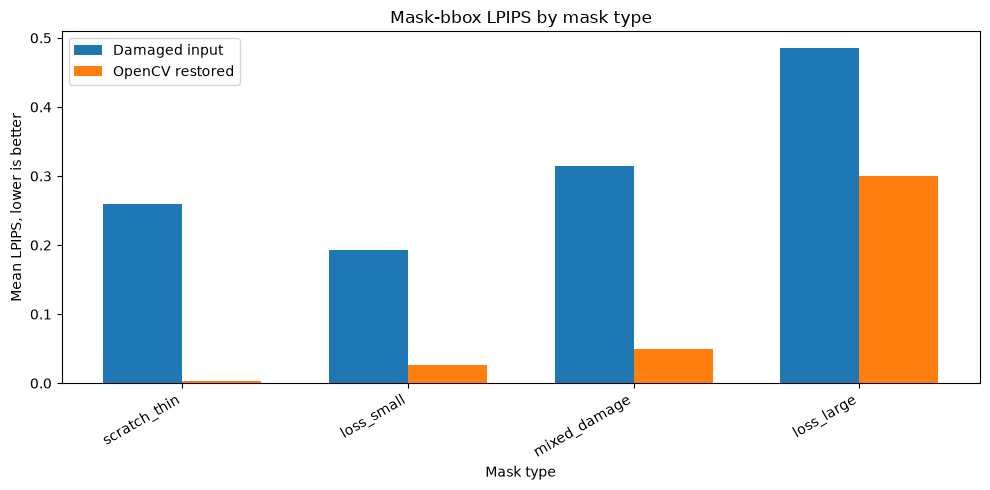

In [16]:
# Diagnostic plots for LPIPS summaries

plot_df = summary_by_region_mask_type_df[
    summary_by_region_mask_type_df["evaluation_region"] == "mask_bbox_crop"
].sort_values("mean_restored_lpips")

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(plot_df))
width = 0.35

ax.bar(
    x - width / 2,
    plot_df["mean_damaged_lpips"],
    width,
    label="Damaged input",
)

ax.bar(
    x + width / 2,
    plot_df["mean_restored_lpips"],
    width,
    label="OpenCV restored",
)

ax.set_title("Mask-bbox LPIPS by mask type")
ax.set_xlabel("Mask type")
ax.set_ylabel("Mean LPIPS, lower is better")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["mask_type"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

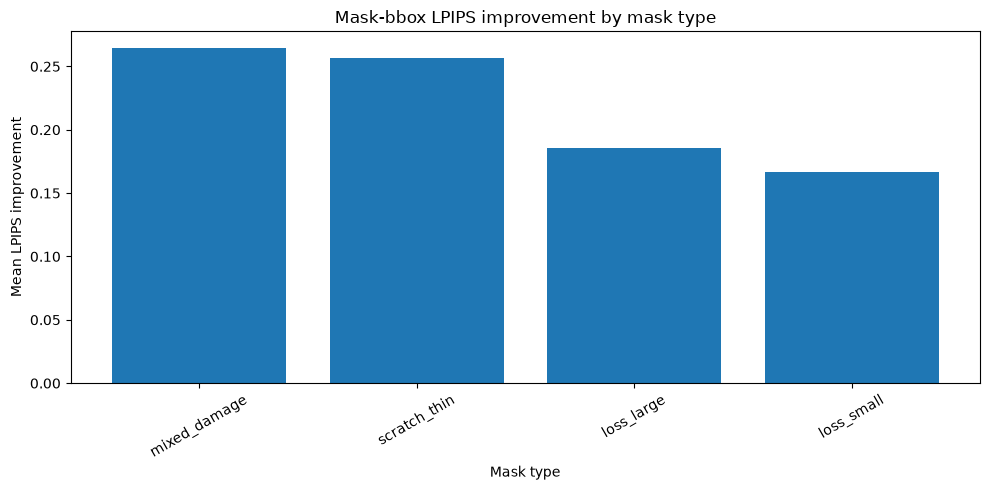

In [17]:
# Diagnostic plot: LPIPS improvement by mask type on mask bounding-box crops

plot_df = summary_by_region_mask_type_df[
    summary_by_region_mask_type_df["evaluation_region"] == "mask_bbox_crop"
].sort_values("mean_lpips_improvement", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    plot_df["mask_type"],
    plot_df["mean_lpips_improvement"],
)

ax.set_title("Mask-bbox LPIPS improvement by mask type")
ax.set_xlabel("Mask type")
ax.set_ylabel("Mean LPIPS improvement")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Interpretation of LPIPS and classical metric disagreement

LPIPS broadly confirms that OpenCV-restored images are perceptually closer to the clean references than the damaged inputs, especially in mask bounding-box crops. However, LPIPS rankings only moderately agree with masked-region MSE rankings. This shows that pixel-level improvement and perceptual feature-space improvement are related but not equivalent.

Some cases show large MSE improvement but weaker LPIPS improvement, suggesting that OpenCV reduced raw pixel error without producing equally strong perceptual recovery. Other cases show relatively modest MSE improvement but stronger LPIPS improvement, indicating that perceptual similarity can improve even when pixel-error reduction is less dramatic.

This supports the thesis argument that restoration quality should not be judged using a single metric family. Classical, perceptual, visual diagnostic, and later feature-based metrics are needed together to characterize restoration behavior.

## LPIPS metric evaluation result

LPIPS perceptual metrics were computed for the OpenCV Telea baseline on the 50-painting controlled subset.

The evaluation compared:

- clean image vs damaged image,
- clean image vs OpenCV-restored image.

LPIPS was computed for image-like spatial regions:

- full image,
- painting content region,
- mask bounding-box crop.

Sparse masked pixels were not used directly for LPIPS because LPIPS expects spatial image inputs rather than unordered pixel sets.

Summary:

- 700 LPIPS metric rows were generated,
- zero-control cases produced near-zero LPIPS values,
- LPIPS summaries were saved by region, mask type, category, region-mask type, and region-category,
- strongest and weakest LPIPS-improvement cases were exported,
- LPIPS rankings were compared against classical masked-region MSE rankings,
- metric-disagreement cases were exported for later qualitative analysis.

The LPIPS results complement the classical metric results by measuring perceptual feature-space similarity rather than direct pixel error. Positive LPIPS improvement means that the OpenCV-restored image is perceptually closer to the clean reference than the damaged input.

The comparison between LPIPS and classical metrics is especially important because pixel-level improvement does not necessarily imply perceptually faithful or semantically correct restoration. Cases where MSE improvement and LPIPS improvement disagree are useful diagnostic examples for the final evaluation framework.